#### Load Datasets

In [17]:
%store -r X_train_scaled
%store -r X_test_scaled
%store -r X_scaled
%store -r y_train
%store -r y_test
%store -r y_dataset

#### Libraries

In [18]:
import pandas as pd
import numpy as np

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, log_loss, confusion_matrix, roc_auc_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_validate, KFold

import matplotlib.pyplot as plt

#### K-Nearest Neighbours

In [19]:
param_grid = {
    'n_neighbors': [3, 5, 7, 15, 25, 50, 100, 150, 250], 
    'weights': ['uniform', 'distance'],
    'p': [1, 2]  # 1 for Manhattan distance, 2 for Euclidean distance
}

knn_classifier = KNeighborsClassifier()

grid_search = GridSearchCV(knn_classifier, param_grid, cv=5, scoring='accuracy')

y_train_array = y_train.values.ravel()
grid_search.fit(X_train_scaled, y_train_array)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f'Best Parameters: {best_params}')
print(f'Best Mean Cross-Validated Score: {best_score}')

knn_classifier = KNeighborsClassifier(**best_params)
knn_classifier.fit(X_train_scaled, y_train_array)

Best Parameters: {'n_neighbors': 3, 'p': 2, 'weights': 'distance'}
Best Mean Cross-Validated Score: 0.625


KNeighborsClassifier(n_neighbors=3, weights='distance')

#### Evaluation on Training Data

In [20]:
y_train_pred = knn_classifier.predict(X_train_scaled)

# Precision
knn_precision_train = precision_score(y_train_array, y_train_pred, average='weighted')

# Recall
knn_recall_train = recall_score(y_train_array, y_train_pred, average='weighted')

# F1-Score
knn_f1_train = f1_score(y_train_array, y_train_pred, average='weighted')

# Classification Accuracy
knn_accuracy_train = accuracy_score(y_train_array, y_train_pred)

# Confusion Matrix
knn_conf_matrix_train = confusion_matrix(y_train_array, y_train_pred)

# Evaluation Metrics
print(f'\nTest Confusion Matrix:\n{knn_conf_matrix_train}')
print(f'Test Accuracy: {knn_accuracy_train}')
print(f'Test F1-Score: {knn_f1_train}')
print(f'Test Precision: {knn_precision_train}')
print(f'Test Recall: {knn_recall_train}')


Test Confusion Matrix:
[[100   0   0   0]
 [  0 153   0   0]
 [  0   0 149   0]
 [  0   0   0 198]]
Test Accuracy: 1.0
Test F1-Score: 1.0
Test Precision: 1.0
Test Recall: 1.0


#### Evaluation on Test Data

In [21]:
y_test_pred = knn_classifier.predict(X_test_scaled)

# Precision
knn_precision_test = precision_score(y_test, y_test_pred, average='weighted')
%store knn_precision_test

# Recall
knn_recall_test = recall_score(y_test, y_test_pred, average='weighted')
%store knn_recall_test

# F1-Score
knn_f1_test = f1_score(y_test, y_test_pred, average='weighted')
%store knn_f1_test

# Classification Accuracy
knn_accuracy_test = accuracy_score(y_test, y_test_pred)
%store knn_accuracy_test

# Confusion Matrix
knn_conf_matrix_test = confusion_matrix(y_test, y_test_pred)
%store knn_conf_matrix_test

# Evaluation Metrics
print(f'\nTest Confusion Matrix:\n{knn_conf_matrix_test}')
print(f'Test Accuracy: {knn_accuracy_test}')
print(f'Test F1-Score: {knn_f1_test}')
print(f'Test Precision: {knn_precision_test}')
print(f'Test Recall: {knn_recall_test}')

Stored 'knn_precision_test' (float64)
Stored 'knn_recall_test' (float64)
Stored 'knn_f1_test' (float64)
Stored 'knn_accuracy_test' (float)
Stored 'knn_conf_matrix_test' (ndarray)

Test Confusion Matrix:
[[ 2  8 10  5]
 [ 1  7 13  4]
 [ 3  6 14  2]
 [ 4  6  2 13]]
Test Accuracy: 0.36
Test F1-Score: 0.33790718210361065
Test Precision: 0.33997507122507126
Test Recall: 0.36


### Plot Results
#### Confusion Matrix

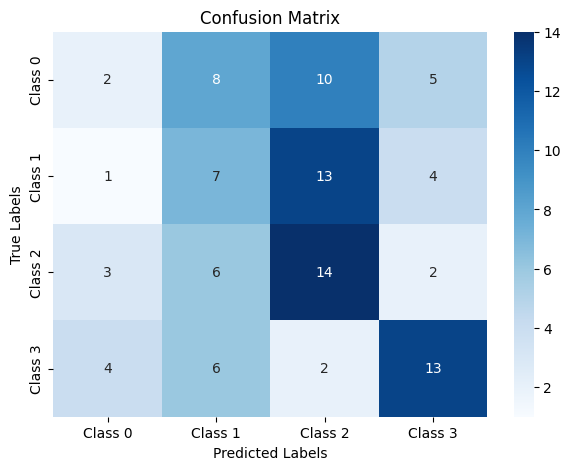

In [22]:
conf_matrix = confusion_matrix(y_test, y_test_pred)

# Plot confusion matrix 
plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix, annot=True, fmt='g', cmap='Blues', xticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'], yticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#### Precision, Recall, F1 Score, Accuracy

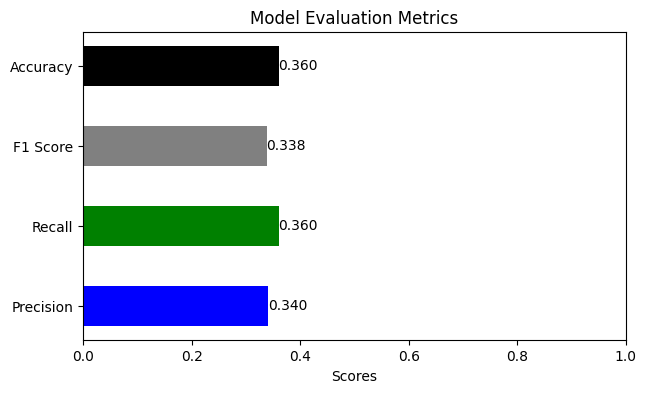

In [23]:
fig, ax = plt.subplots(figsize=(7, 4))
metrics = ['Precision', 'Recall', 'F1 Score', 'Accuracy']
scores = [knn_precision_test, knn_recall_test, knn_f1_test, knn_accuracy_test]
bar_width = 0.5

# Plot horizontal bars
bars = ax.barh(metrics, scores, height=bar_width, color=['blue', 'green', 'grey', 'black'])

# Display actual values 
for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.3f}', 
             va='center', ha='left', color='black')

ax.set_xlabel('Scores')
ax.set_title('Model Evaluation Metrics')

ax.set_xlim(0, 1)
plt.show()

#### K-Nearest Neighbours with 5fold Cross Validation

In [24]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
knn_5cross = KNeighborsClassifier()

scoring_metrics = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']

cv_results = cross_validate(knn_5cross, X_scaled, y_dataset, cv=kf, scoring=scoring_metrics, return_train_score=False)

for fold in range(1, kf.get_n_splits() + 1):
    print(f"Fold {fold} Metrics:")
    print(f"Accuracy: {cv_results['test_accuracy'][fold-1]}")
    print(f"Precision: {cv_results['test_precision_weighted'][fold-1]}")
    print(f"Recall: {cv_results['test_recall_weighted'][fold-1]}")
    print(f"F1 Score: {cv_results['test_f1_weighted'][fold-1]}")
    print("--"*100)

mean_metrics = {metric: np.mean(cv_results[f'test_{metric}']) for metric in scoring_metrics}

print("Mean Metrics Across Folds:")
for metric, value in mean_metrics.items():
    if metric == 'neg_log_loss':
        value = abs(value)
    print(f"{metric}: {value}")

Fold 1 Metrics:
Accuracy: 0.36428571428571427
Precision: 0.36585442585442585
Recall: 0.36428571428571427
F1 Score: 0.36487330936483475
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Fold 2 Metrics:
Accuracy: 0.2714285714285714
Precision: 0.2735304165258083
Recall: 0.2714285714285714
F1 Score: 0.2712888424361027
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Fold 3 Metrics:
Accuracy: 0.3
Precision: 0.3853787878787879
Recall: 0.3
F1 Score: 0.31446739007497987
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Fold 4 Metrics:
Accuracy: 0.2

##### Plot the Cross Valdation Results

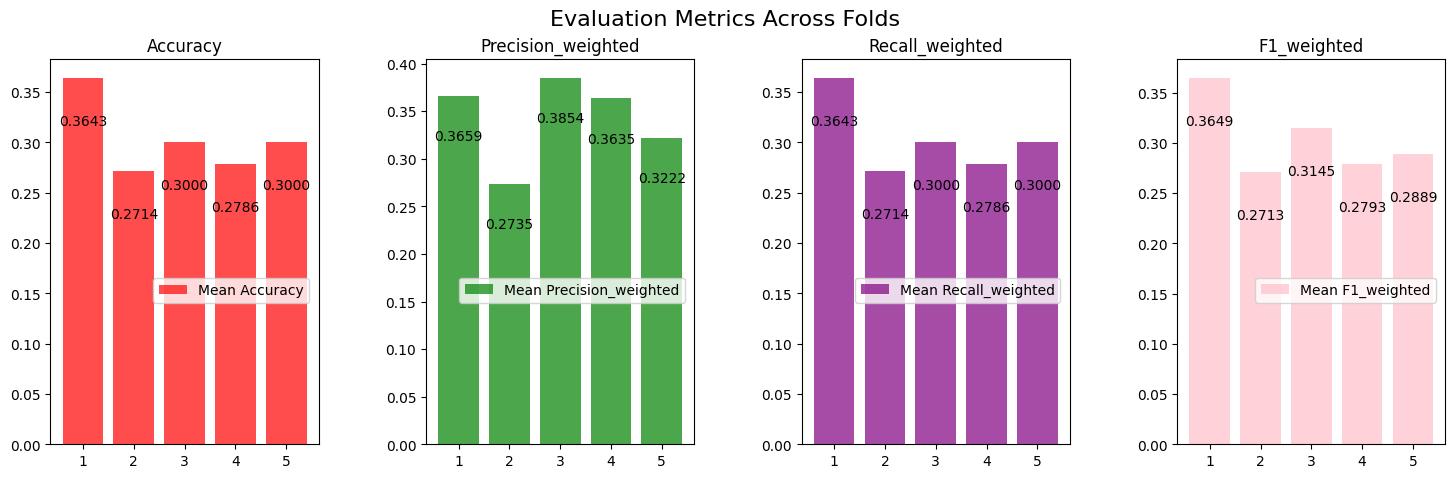

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(18, 5))
fig.suptitle('Evaluation Metrics Across Folds', fontsize=16)

# Function για τς τιμές μέσα στις μπάρες
def add_values(ax, values):
    for i, value in enumerate(values):
        ax.text(i + 1, value - 0.05, f'{value:.4f}', ha='center', va='bottom', color='black')

bar_height = 0.5
metrics_to_plot = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted']
colors = ['red', 'green', 'purple', 'pink']

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    metric_values = cv_results[f'test_{metric}']

    bars = axes[idx].bar(range(1, kf.get_n_splits() + 1), metric_values, color=color, alpha=0.7)
    axes[idx].set_title(metric.capitalize())
    add_values(axes[idx], metric_values)

    axes[idx].legend([f'Mean {metric.capitalize()}'], loc='center right', bbox_to_anchor=(0.99, 0.4))

plt.subplots_adjust(wspace=0.4)
plt.show()